# Sparse regression by hand: the SIR epidemic model

**Goal.** Implement the core idea of SINDy (Brunton, Proctor & Kutz, 2016) from scratch — build a library of candidate functions, solve a least-squares problem, threshold small coefficients — and check that it recovers the SIR equations.

The SIR model splits a population into **S**usceptible, **I**nfected and **R**ecovered fractions:

$$
\begin{aligned}
\dot s &= -\beta\, s\, i \\
\dot i &= \beta\, s\, i - \gamma\, i \\
\dot r &= \gamma\, i
\end{aligned}
$$

with infection rate $\beta$ and recovery rate $\gamma$. The only nonlinearity is the contact term $s\,i$, so the model is sparse in a quadratic polynomial library — a textbook SINDy case.

A second point of the notebook is **conservation**: $\dot s + \dot i + \dot r = 0$, so $s+i+r = 1$ for all time. This makes a naive library rank-deficient, which is the same issue that will appear in attrition models where total force size or resources are conserved or constrained.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Ground-truth model

$\beta = 0.5$, $\gamma = 0.1$, so the basic reproduction number is $R_0 = \beta/\gamma = 5$.

In [2]:
beta = 0.5
gamma = 0.1

def dsdt(s,i):
    return -beta*s*i

def didt(s,i):
    return beta*s*i-gamma*i

def drdt(i):
    return gamma*i

def f(X,t):
    s,i,r = X

    return np.array([dsdt(s,i),
                     didt(s,i),
                     drdt(i)]).T


## 2. Simulating the data

Initial state: 99 % susceptible, 1 % infected. `np.arange(n)*dt` is used so the sampling step really is `dt` (`np.linspace(0, 100, 1000)` gives a step of $100/999$).

In [3]:
T = 100
dt = 0.1
n_samples = int(T/dt)

t = np.arange(n_samples) * dt

s0, i0, r0 = 0.99, 0.01, 0

X0 = np.array([s0,i0,r0]).T

In [4]:
from scipy.integrate import odeint

X = odeint(f,X0,t)
s,i,r = X.T

s.shape, i.shape, r.shape, X.shape


((1000,), (1000,), (1000,), (1000, 3))

The derivatives are computed **exactly** by evaluating the right-hand side at each state. This is the idealised setting — there is no differentiation error — so any failure below is caused by the regression setup, not by the data.

In [5]:
X_dot = np.zeros(X.shape) #This represents exact derivatives
for k,state in enumerate(X):
    X_dot[k] = f(state,t[k])


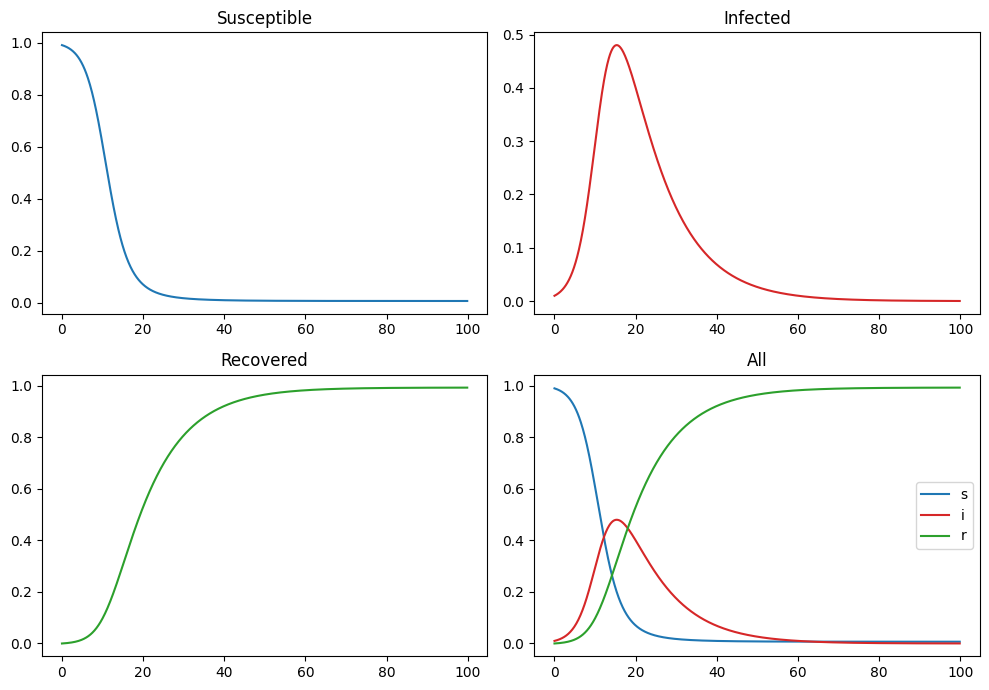

In [6]:
plt.figure(figsize=(10, 7))

plt.subplot(2,2,1)
plt.plot(t, s, label='s')
plt.title('Susceptible')

plt.subplot(2,2,2)
plt.plot(t, i, label='i', color='tab:red')
plt.title('Infected')

plt.subplot(2,2,3)
plt.plot(t, r, label='r', color='tab:green')
plt.title('Recovered')

plt.subplot(2,2,4)
plt.plot(t, s, label='s')
plt.plot(t, i, label='i', color='tab:red')
plt.plot(t, r, label='r', color='tab:green')
plt.title('All')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Building the candidate library

SINDy writes the dynamics as $\dot X = \Theta(X)\,\Xi$, where each column of $\Theta(X)$ is a candidate function evaluated on the data and $\Xi$ is a sparse coefficient matrix.

Two libraries are defined:

- `create_lib`: all monomials of degree 1–2 in $(s, i, r)$ (no constant).
- `create_lib_no_r`: constant plus monomials of degree 1–2 in $(s, i)$ only.

**Why drop $r$?** Because $s + i + r = 1$, the columns are linearly dependent:

- $s + i + r = 1$ ⇒ the linear columns are collinear with the constant.
- $s^2 + s\,i + s\,r = s(s+i+r) = s$ ⇒ the quadratic columns are collinear with the linear ones, *even without a constant column*.

With a rank-deficient $\Theta$ there are infinitely many $\Xi$ that fit the data equally well, so the "sparse" solution is not unique. Since $r = 1 - s - i$ carries no extra information, it can be removed.

In [7]:
def create_lib(X):
    s, i, r = X.T
    return np.column_stack([
        s, i, r,
        s**2, s*i, s*r,
        i**2, i*r,
        r**2,
    ])

def create_lib_no_r(X):
    s, i, r = X.T
    return np.column_stack([
        np.ones_like(s),
        s, i,
        s**2, s*i,
        i**2, 
    ])

    
Lib = create_lib_no_r(X)

## 4. Least squares

The original notebook solved the normal equations $\Xi = (\Theta^\top\Theta)^{-1}\Theta^\top \dot X$. This squares the condition number of $\Theta$; `np.linalg.lstsq` solves the same problem more stably and is the standard choice.

In [8]:
xi, *_ = np.linalg.lstsq(Lib, X_dot, rcond=None)
xi

array([[-9.98679718e-18,  7.61608838e-18, -9.35182098e-19],
       [ 1.06858966e-15, -1.93725244e-15, -5.06539255e-16],
       [-1.27323244e-16, -1.00000000e-01,  1.00000000e-01],
       [-1.07159893e-15,  1.85148036e-15,  5.89217879e-16],
       [-5.00000000e-01,  5.00000000e-01,  6.58289730e-16],
       [ 2.80861774e-16, -2.94288924e-16,  4.38791399e-17]])

## 5. Thresholding

With exact derivatives the unwanted coefficients are at round-off level ($\sim 10^{-12}$), so one hard threshold is enough. With noisy data the gap between true and spurious terms shrinks, and the iterative *sequential thresholded least squares* (STLSQ) of Brunton et al. — threshold, refit on the surviving terms, repeat — is needed instead.

In [9]:
xi_filtered = np.where(np.abs(xi)>1e-10,xi,0)


In [10]:
#Lib_ functions -> [1,s,i,s^2,si,i^2]
xi_filtered

array([[ 0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ],
       [ 0. , -0.1,  0.1],
       [ 0. ,  0. ,  0. ],
       [-0.5,  0.5,  0. ],
       [ 0. ,  0. ,  0. ]])

In [11]:
names = ["1", "s", "i", "s^2", "s i", "i^2"]
for k, lhs in enumerate(["ds/dt", "di/dt", "dr/dt"]):
    terms = [f"{xi_filtered[j, k]:+.3f} {names[j]}" for j in range(len(names)) if xi_filtered[j, k] != 0]
    print(f"{lhs} = {' '.join(terms)}")

ds/dt = -0.500 s i
di/dt = -0.100 i +0.500 s i
dr/dt = +0.100 i


**Result.** Exactly the true model:

$$\dot s = -0.5\, s i, \qquad \dot i = 0.5\, s i - 0.1\, i, \qquad \dot r = 0.1\, i .$$

## 6. Checking the conservation law and library rank

The first plot confirms $s+i+r = 1$ throughout. The rank check shows that the full library loses rank, while the reduced library has full column rank.

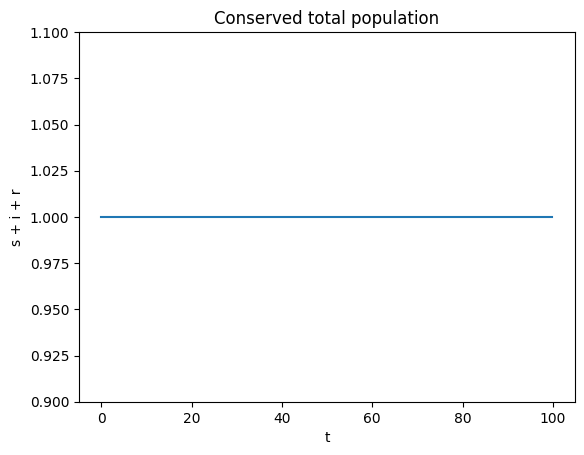

full library (s, i, r):  9 columns, rank 6
reduced library (s, i):  6 columns, rank 6


In [12]:
sum_states = np.sum(X, axis=1)
plt.plot(t, sum_states)
plt.ylim(0.9, 1.1)
plt.xlabel("t")
plt.ylabel("s + i + r")
plt.title("Conserved total population")
plt.show()

Lib_full = create_lib(X)
print(f"full library (s, i, r):  {Lib_full.shape[1]} columns, rank {np.linalg.matrix_rank(Lib_full)}")
print(f"reduced library (s, i):  {Lib.shape[1]} columns, rank {np.linalg.matrix_rank(Lib)}")

## Takeaways and possible next steps

- The hand-written pipeline ($\Theta$, least squares, threshold) recovers SIR exactly with clean derivatives.
- **Conserved quantities make libraries rank-deficient.** Either eliminate a redundant state (as here), or impose the constraint in the optimiser (PySINDy's `ConstrainedSR3` supports linear equality constraints on $\Xi$).
- Next experiments: estimate $\dot X$ by finite differences instead of using exact derivatives, add measurement noise, replace the one-shot threshold with STLSQ, and compare against `ps.SINDy` on the same data.